# Calo Clustering Studies

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import uproot
import sys
import time
from tqdm import tqdm
from pathlib import Path
import atlasify as atl
atl.ATLAS = "ColliderML"

sys.path.append("../")
from edm4hep_utils import load_edm4hep_file, create_truth_clusters
from clustering_metrics import evaluate_clustering, plot_clustering_metrics

## Roadmap

1. Load and process file for calo hits
2. Try a very simple clustering algorithm
3. Evaluate clustering metrics
4. Try a more complex clustering algorithm
5. Evaluate clustering metrics

## Load in edm4hep file

### ECal Barrel Collection

In [2]:
edm4hep_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/outputs/python_submission_tests/v1_testing/runs/0/edm4hep.root"
# all_events = load_edm4hep_file(edm4hep_file)
event = load_edm4hep_file(edm4hep_file, event_num=0)

In [3]:
calo_hits_df = create_truth_clusters(event, detector='ECalBarrelCollection')

/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/colliderml_dev/notebooks/physics/../edm4hep_utils.py:304: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cells_df['cellID'] = cells_df['cellID'].astype('uint64')


In [4]:
# Create a mapping of particle IDs to cluster labels
unique_particles = calo_hits_df.highest_energy_particle_id.unique()
particle_to_label = {pid: i for i, pid in enumerate(unique_particles)}

# Create labels array where each cell gets the cluster label corresponding to its particle
labels_pred = calo_hits_df.highest_energy_particle_id.map(particle_to_label)
calo_hits_df['labels_pred'] = labels_pred


### Truth Test

In [28]:
mixed_labels_df

,cellID,energy,x,y,z,contribution_begin,contribution_end,r,R,phi,theta,eta,detector,highest_energy_particle_id,labels_pred
0,19703278443040784,1.836892e-09,35.700001,-1267.550049,357.000000,0,1,1268.052734,1317.348389,-1.542639,1.296366,0.277942,ECalBarrelCollection,96703,37458
1,18291088463137206288,6.815690e-06,1343.300049,61.200001,-2820.300049,1,2,1344.693481,3124.466797,0.045528,2.696684,-1.486345,ECalBarrelCollection,96900,31744
2,18292495838020694032,7.979669e-06,1333.199951,61.200001,-2794.800049,2,3,1334.603882,3097.107422,0.045872,2.696081,-1.484945,ECalBarrelCollection,96900,1
3,18310510159220439056,6.901636e-07,1173.350220,-519.138733,-2473.500000,3,4,1283.064941,2786.477783,-0.416550,2.663078,-1.410875,ECalBarrelCollection,96897,2
4,18327961818231109648,4.109088e-06,1441.609619,-359.765656,-2152.199951,4,5,1485.822876,2615.269287,-0.244563,2.537356,-1.165847,ECalBarrelCollection,97236,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355595,168322186405959696,3.216178e-07,354.943817,1323.353149,3049.800049,1632713,1632714,1370.127197,3343.430664,1.308748,0.422231,1.540336,ECalBarrelCollection,1850,43333
355596,163255602465495056,7.675362e-07,396.503204,1317.070801,2958.000000,1632714,1632715,1375.459961,3262.154785,1.278377,0.435255,1.509007,ECalBarrelCollection,1850,22944
355597,163537064557434896,1.236313e-08,418.368774,1329.878174,2963.100098,1632715,1632716,1394.133545,3274.686279,1.266007,0.439769,1.498352,ECalBarrelCollection,1850,10580
355598,167759068948813840,1.204739e-05,538.703430,1247.237427,3034.500000,1632716,1632717,1358.603149,3324.754639,1.163081,0.420955,1.543454,ECalBarrelCollection,1850,37864


In [5]:
# Let's mix up the labels a bit
fraction_to_mix = 0.5
mixed_labels = calo_hits_df.labels_pred.copy()
mixed_labels[np.random.choice(calo_hits_df.index, size=int(len(calo_hits_df)*fraction_to_mix), replace=False)] = np.random.randint(0, int(calo_hits_df.labels_pred.max()), size=int(len(calo_hits_df)*fraction_to_mix))
mixed_labels_df = calo_hits_df.copy()
mixed_labels_df['labels_pred'] = mixed_labels

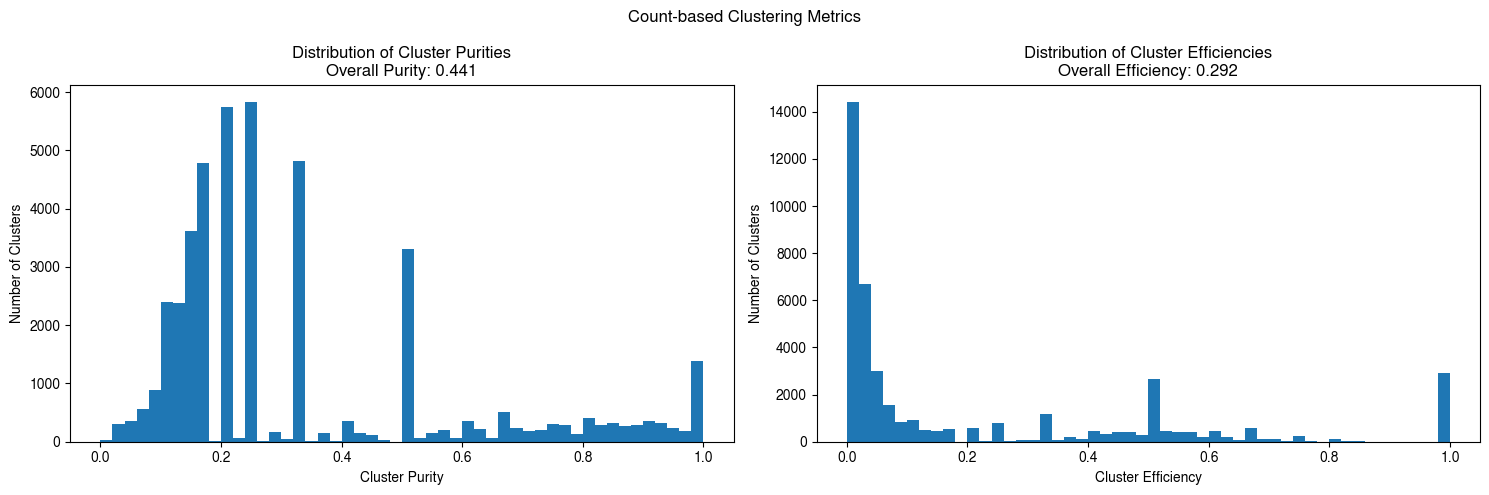

In [11]:
metrics_df, overall = evaluate_clustering(mixed_labels_df, energy_weighted=False, label_column='labels_pred', energy_column='energy', particle_id_column='highest_energy_particle_id')

# Plot results
plot_clustering_metrics(metrics_df, overall)

In [12]:
metrics_df

,energy,dominant_particle_id,total_cells,correct_cells,purity,total_particle_cells,efficiency
labels_pred,,,,,,,
0,0.000261,88523,4,1,0.250000,61,0.016393
1,0.000566,2316128,5,1,0.200000,9,0.111111
2,0.000196,50463,4,1,0.250000,98,0.010204
3,0.000513,4049250,7,1,0.142857,169,0.005917
4,0.001049,86134,4,1,0.250000,10,0.100000
...,...,...,...,...,...,...,...
43329,0.000259,1748363,5,1,0.200000,82,0.012195
43330,0.001025,20377,5,1,0.200000,18,0.055556
43331,0.000285,2349727,7,1,0.142857,14,0.071429


### Create particle-wise efficiency

Testing count-based metrics...

Cluster Metrics:
               energy  dominant_particle_id  total_cells  correct_cells  \
labels_pred                                                               
0            3.985650                     1           11              5   
1            0.795446                     2            4              4   
2            3.761620                     1            5              5   

               purity  total_particle_cells  efficiency  
labels_pred                                              
0            0.454545                    10         0.5  
1            1.000000                    10         0.4  
2            1.000000                    10         0.5  

Overall Metrics:
{'purity': 0.7, 'clusterwise_efficiency': 0.48, 'particlewise_efficiency': 0.7, 'energy_weighted': False}

Particle Metrics:
             particle_efficiency  n_dominant_clusters  total_cells
particle_id                                                       
1       

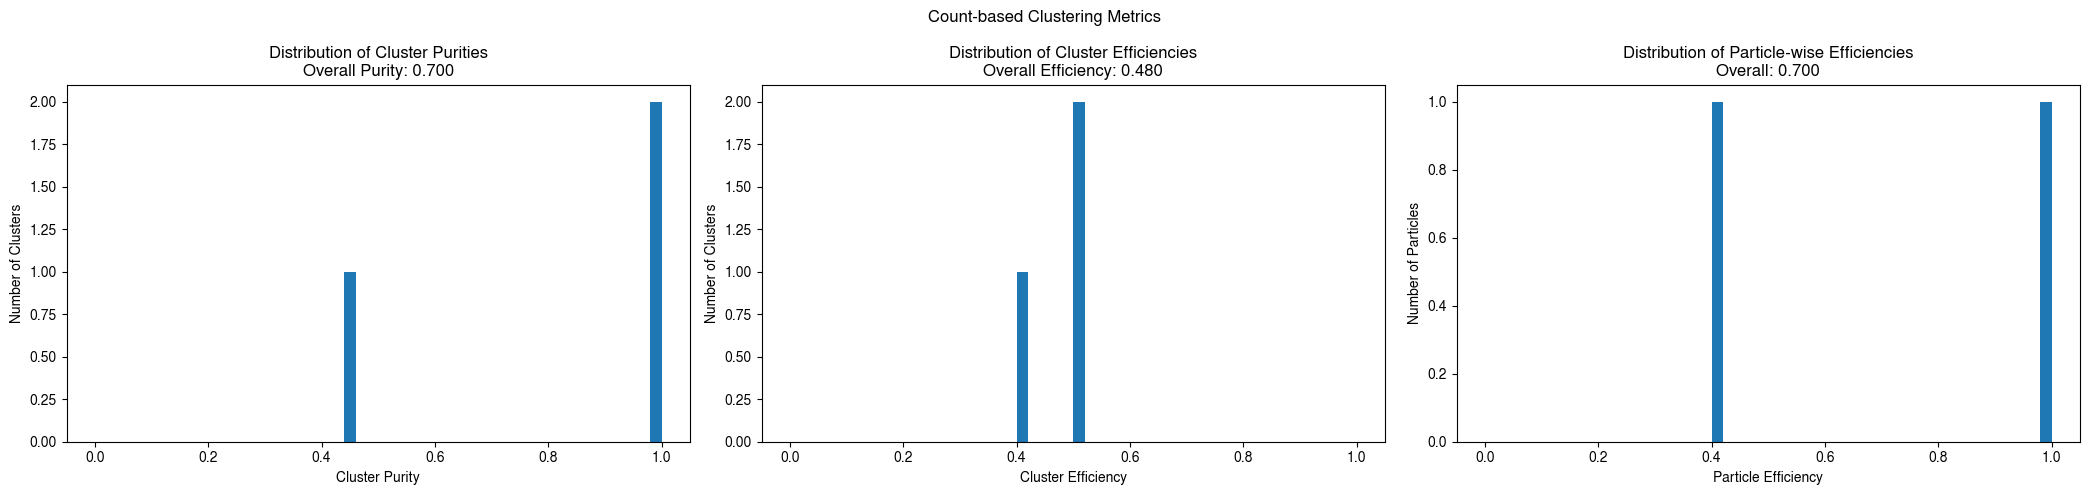

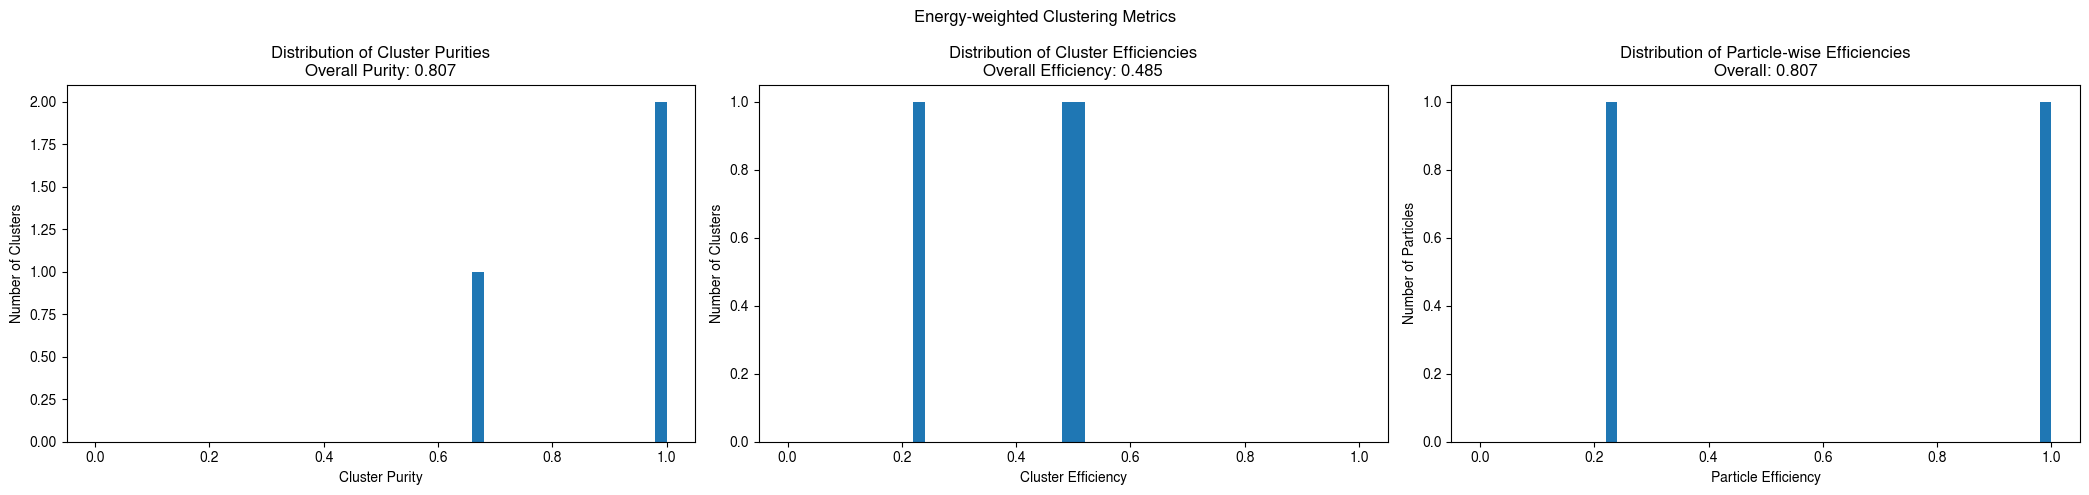

In [31]:
data = []

# Particle 1: Well clustered (high efficiency)
# 10 cells, all in one cluster (cluster 0)
for i in range(5):
    data.append({
        'particle_id': 1,
        'labels_pred': 0,
        'energy': np.random.uniform(3, 4)
    })
for i in range(5):
    data.append({
        'particle_id': 1,
        'labels_pred': 2,
        'energy': np.random.uniform(3, 4)
    })


# Particle 2: Split across clusters (medium efficiency)
# 10 cells split between clusters 1 and 2
for i in range(6):
    data.append({
        'particle_id': 2,
        'labels_pred': 0,
        'energy': np.random.uniform(1, 2)
    })
for i in range(4):
    data.append({
        'particle_id': 2,
        'labels_pred': 1,
        'energy': np.random.uniform(0.5, 1)
    })


df = pd.DataFrame(data)


# Test count-based metrics
print("Testing count-based metrics...")
cluster_metrics, overall_metrics, particle_metrics = evaluate_clustering(
    df, energy_weighted=False
)

print("\nCluster Metrics:")
print(cluster_metrics)
print("\nOverall Metrics:")
print(overall_metrics)
print("\nParticle Metrics:")
print(particle_metrics)

# Test energy-weighted metrics
print("\nTesting energy-weighted metrics...")
cluster_metrics_ew, overall_metrics_ew, particle_metrics_ew = evaluate_clustering(
    df, energy_weighted=True
)

print("\nEnergy-Weighted Cluster Metrics:")
print(cluster_metrics_ew)
print("\nEnergy-Weighted Overall Metrics:")
print(overall_metrics_ew)
print("\nEnergy-Weighted Particle Metrics:")
print(particle_metrics_ew)

# Plot both versions
print("\nGenerating plots...")
plot_clustering_metrics(cluster_metrics, overall_metrics, particle_metrics)
plot_clustering_metrics(cluster_metrics_ew, overall_metrics_ew, particle_metrics_ew)

In [32]:
df

,particle_id,labels_pred,energy
0,1,0,3.908266
1,1,0,3.239562
2,1,0,3.144895
3,1,0,3.489453
4,1,0,3.985650
5,1,2,3.242055
6,1,2,3.672136
7,1,2,3.761620
8,1,2,3.237638
9,1,2,3.728216


In [33]:
cluster_metrics

,energy,dominant_particle_id,total_cells,correct_cells,purity,total_particle_cells,efficiency
labels_pred,,,,,,,
0,3.985650,1,11,5,0.454545,10,0.5
1,0.795446,2,4,4,1.000000,10,0.4
2,3.761620,1,5,5,1.000000,10,0.5


In [34]:
overall_metrics

{'purity': 0.7,
 'clusterwise_efficiency': 0.48,
 'particlewise_efficiency': 0.7,
 'energy_weighted': False}

In [35]:
particle_metrics

,particle_efficiency,n_dominant_clusters,total_cells
particle_id,,,
1,1.0,2,10
2,0.4,1,10


## Try a simple clustering algorithm

In [36]:
from clustering_algorithms import heuristic_energy_clustering

In [37]:
calo_hits_df = heuristic_energy_clustering(calo_hits_df, seed_fraction=0.1)
calo_hits_df

Seeds: 35560
Remaining: 320040
Buliding KDTree
Querying KDTree
Creating cluster assignments


,cellID,energy,x,y,z,contribution_begin,contribution_end,r,R,phi,theta,eta,detector,highest_energy_particle_id,labels_pred,cluster_id
0,19703278443040784,1.836892e-09,35.700001,-1267.550049,357.000000,0,1,1268.052734,1317.348389,-1.542639,1.296366,0.277942,ECalBarrelCollection,96703,0,17701
1,18291088463137206288,6.815690e-06,1343.300049,61.200001,-2820.300049,1,2,1344.693481,3124.466797,0.045528,2.696684,-1.486345,ECalBarrelCollection,96900,1,17897
2,18292495838020694032,7.979669e-06,1333.199951,61.200001,-2794.800049,2,3,1334.603882,3097.107422,0.045872,2.696081,-1.484945,ECalBarrelCollection,96900,1,17897
3,18310510159220439056,6.901636e-07,1173.350220,-519.138733,-2473.500000,3,4,1283.064941,2786.477783,-0.416550,2.663078,-1.410875,ECalBarrelCollection,96897,2,6976
4,18327961818231109648,4.109088e-06,1441.609619,-359.765656,-2152.199951,4,5,1485.822876,2615.269287,-0.244563,2.537356,-1.165847,ECalBarrelCollection,97236,3,33758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355595,168322186405959696,3.216178e-07,354.943817,1323.353149,3049.800049,1632713,1632714,1370.127197,3343.430664,1.308748,0.422231,1.540336,ECalBarrelCollection,1850,43333,6258
355596,163255602465495056,7.675362e-07,396.503204,1317.070801,2958.000000,1632714,1632715,1375.459961,3262.154785,1.278377,0.435255,1.509007,ECalBarrelCollection,1850,43333,1617
355597,163537064557434896,1.236313e-08,418.368774,1329.878174,2963.100098,1632715,1632716,1394.133545,3274.686279,1.266007,0.439769,1.498352,ECalBarrelCollection,1850,43333,1617
355598,167759068948813840,1.204739e-05,538.703430,1247.237427,3034.500000,1632716,1632717,1358.603149,3324.754639,1.163081,0.420955,1.543454,ECalBarrelCollection,1850,43333,5942


Seeds: 3556
Remaining: 352044
Buliding KDTree
Querying KDTree
Creating cluster assignments


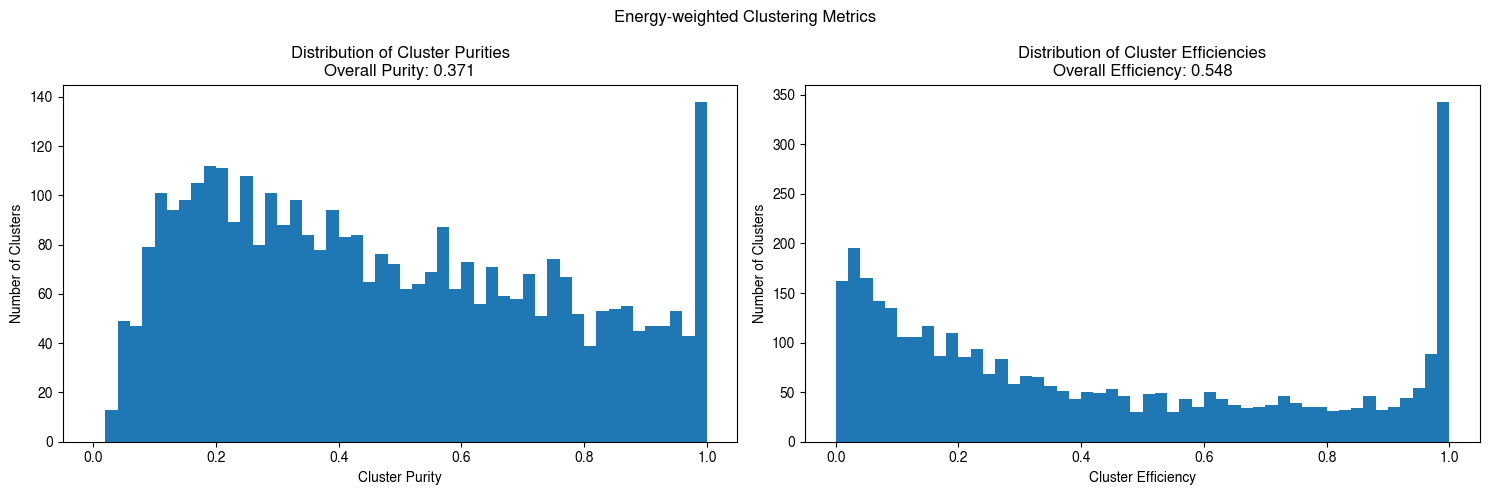

{'purity': 0.3710098, 'efficiency': 0.54787356, 'energy_weighted': True, 'num_clusters': 3556}
Seeds: 17780
Remaining: 337820
Buliding KDTree
Querying KDTree
Creating cluster assignments


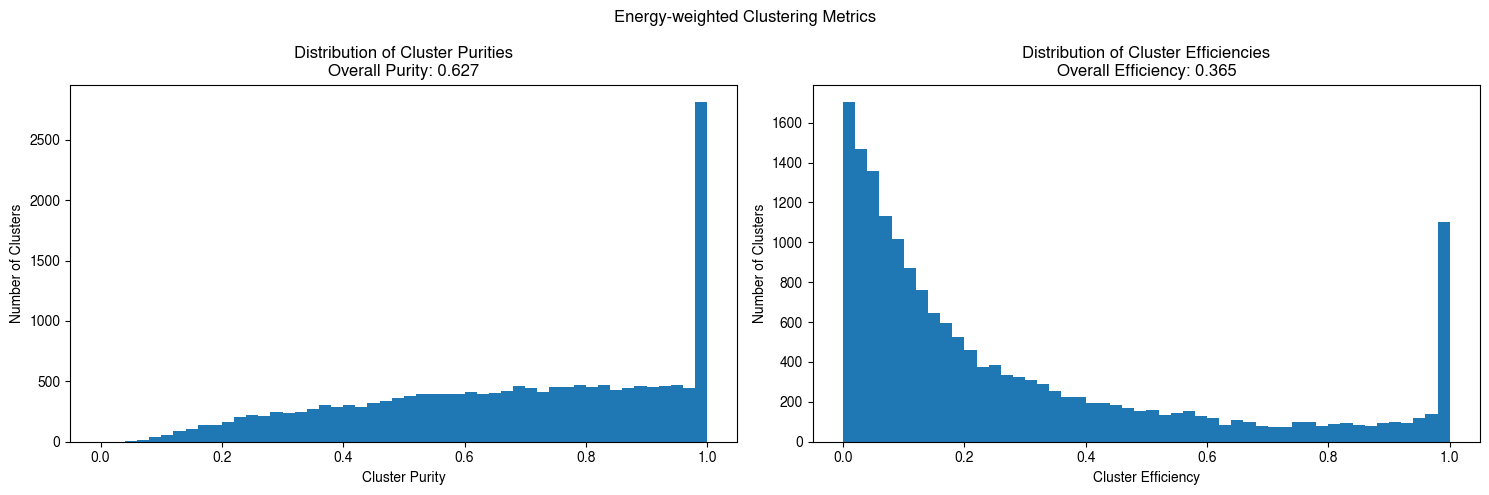

{'purity': 0.6273145, 'efficiency': 0.3652936, 'energy_weighted': True, 'num_clusters': 17780}
Seeds: 35560
Remaining: 320040
Buliding KDTree
Querying KDTree
Creating cluster assignments


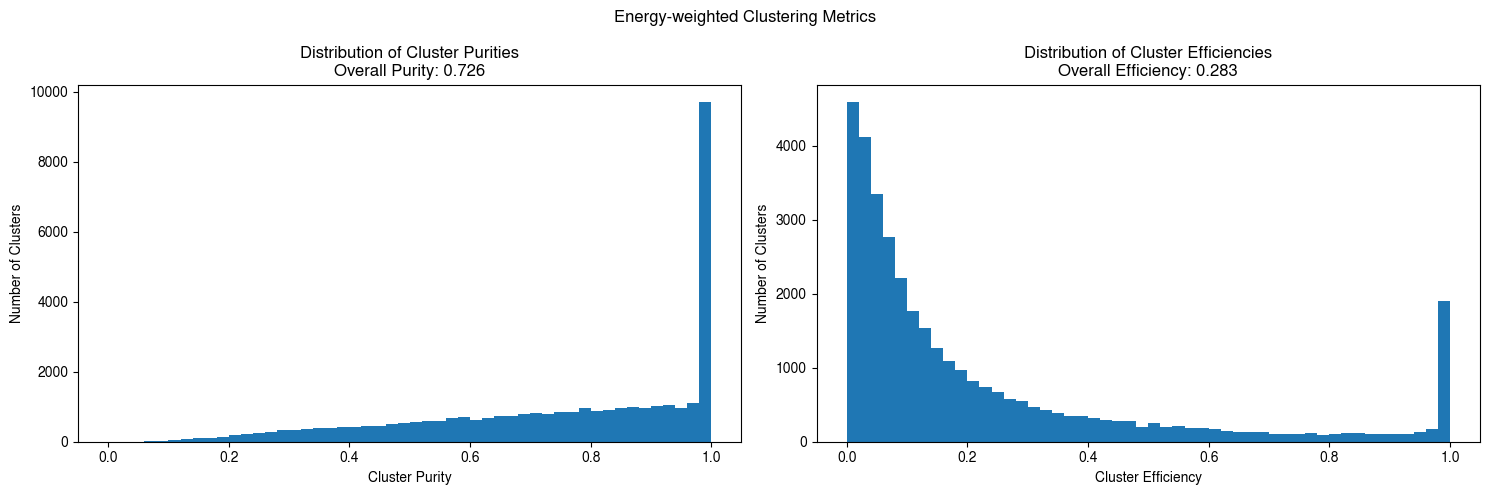

{'purity': 0.7260451, 'efficiency': 0.28321227, 'energy_weighted': True, 'num_clusters': 35560}
Seeds: 71120
Remaining: 284480
Buliding KDTree
Querying KDTree
Creating cluster assignments


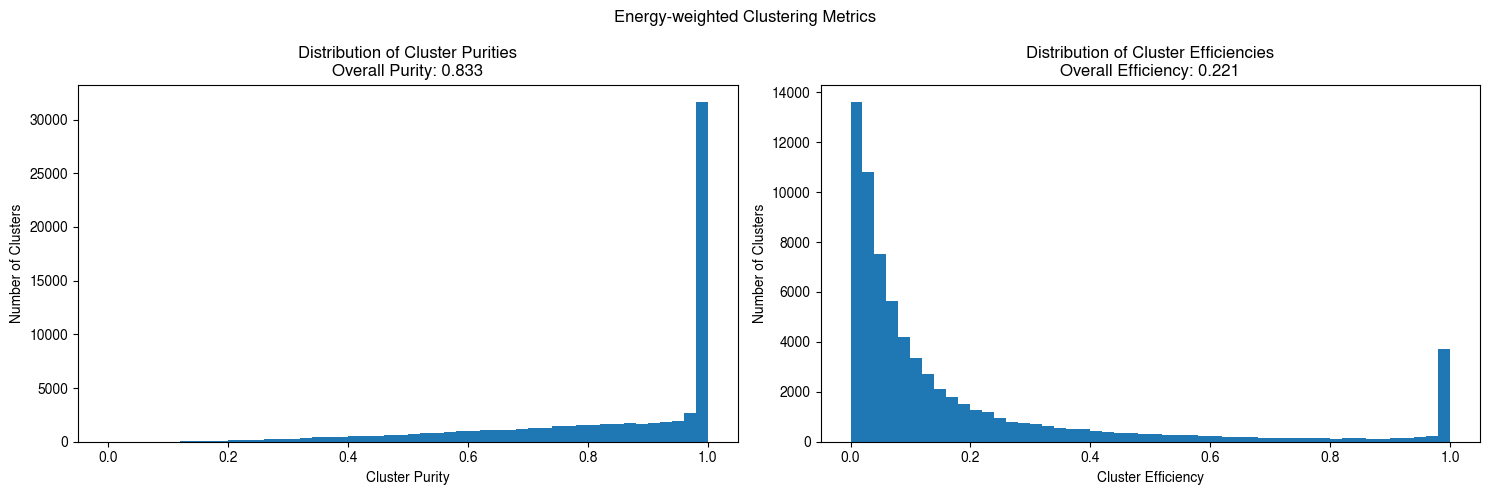

{'purity': 0.8331162, 'efficiency': 0.2214587, 'energy_weighted': True, 'num_clusters': 71120}


In [40]:
for seed_fraction in [0.01, 0.05, 0.1, 0.2]:
    calo_hits_df = heuristic_energy_clustering(calo_hits_df, seed_fraction=seed_fraction)
    metrics_df, overall = evaluate_clustering(calo_hits_df, energy_weighted=True, label_column='cluster_id', energy_column='energy', particle_id_column='highest_energy_particle_id')
    plot_clustering_metrics(metrics_df, overall)
    print(overall)

### K Means (with cheating!)

In [5]:
from sklearn.cluster import KMeans

number_of_particles = calo_hits_df.highest_energy_particle_id.nunique()

OpenBLAS warning: precompiled NUM_THREADS exceeded, adding auxiliary array for thread metadata.


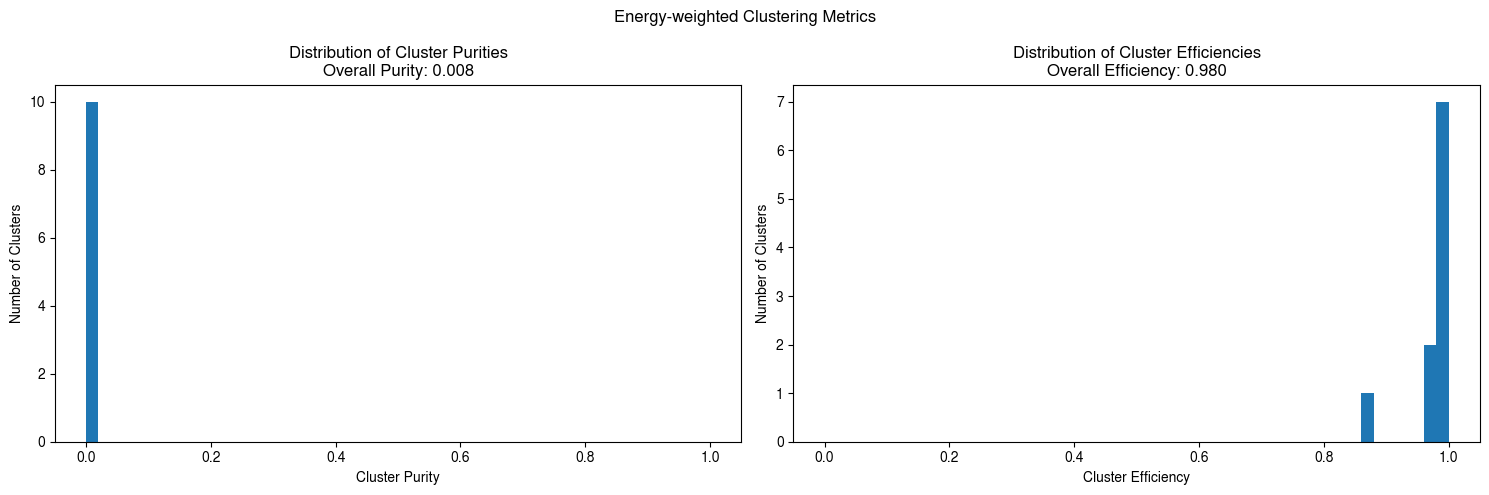

In [6]:

kmeans = KMeans(n_clusters=10)
kmeans.fit(calo_hits_df[['x', 'y', 'z']].values)

calo_hits_df['kmeans_labels'] = kmeans.labels_

metrics_df, overall = evaluate_clustering(calo_hits_df, energy_weighted=True, label_column='kmeans_labels', energy_column='energy', particle_id_column='highest_energy_particle_id')
plot_clustering_metrics(metrics_df, overall)

In [9]:
start_time = time.time()
kmeans = KMeans(n_clusters=50)
kmeans.fit(calo_hits_df[['x', 'y', 'z']].values)
end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")

calo_hits_df['kmeans_labels'] = kmeans.labels_

metrics_df, overall = evaluate_clustering(calo_hits_df, energy_weighted=True, label_column='kmeans_labels', energy_column='energy', particle_id_column='highest_energy_particle_id')
plot_clustering_metrics(metrics_df, overall)

: 

In [26]:
# time

cluster_size_list = [10, 20, 50, 100, 200, 500]

for cluster_size in cluster_size_list:
    start_time = time.time()
    kmeans = KMeans(n_clusters=cluster_size)
    kmeans.fit(calo_hits_df[['x', 'y', 'z']].values)
    end_time = time.time()
    print(f"Time taken: {end_time - start_time} seconds")

    calo_hits_df['kmeans_labels'] = kmeans.labels_

    metrics_df, overall = evaluate_clustering(calo_hits_df, energy_weighted=True, label_column='kmeans_labels', energy_column='energy', particle_id_column='highest_energy_particle_id')
    plot_clustering_metrics(metrics_df, overall)

In [30]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler

# Create a clean, C-contiguous copy of the data
data = np.ascontiguousarray(calo_hits_df[['x', 'y', 'z']].values, dtype=np.float32)

# Normalize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

print("Starting clustering...")
start_time = time.time()

kmeans = MiniBatchKMeans(
    n_clusters=10000,
    batch_size=1000,
    random_state=42,
    max_iter=100,
    verbose=1,
    tol=1e-4  # Add explicit tolerance
)

# Try with normalized data
kmeans.fit(data_scaled)
end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")

# Map labels back to original dataframe
calo_hits_df['kmeans_labels'] = kmeans.labels_

Starting clustering...
Init 1/1 with method k-means++
Inertia for init 1/1: 52.32097625732422
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 1/35560: mean batch inertia: 0.0018041961193084716
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 2/35560: mean batch inertia: 0.0018298095464706421, ewa inertia: 0.0018298095464706421
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 3/35560: mean batch inertia: 0.001884887933731079, ewa inertia: 0.0018301193228056943
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 4/35560: mean batch inertia: 0.001850316047668457, ewa inertia: 0.0018302329148645624
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 5/35560: mean batch inertia: 0.0019142374992370606, ewa inertia: 0.0018307053802646737
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 6/35560: mean batch inertia: 0.0018179813623428345, ewa inertia: 0.0018306338168105672
[MiniBatchKMeans] Reassign

Cluster sizes:
1317    260
3464    214
9794    208
381     194
2566    192
       ... 
2222      2
6831      2
9725      2
2616      2
8276      1
Name: kmeans_labels, Length: 9502, dtype: int64

Total points: 355600


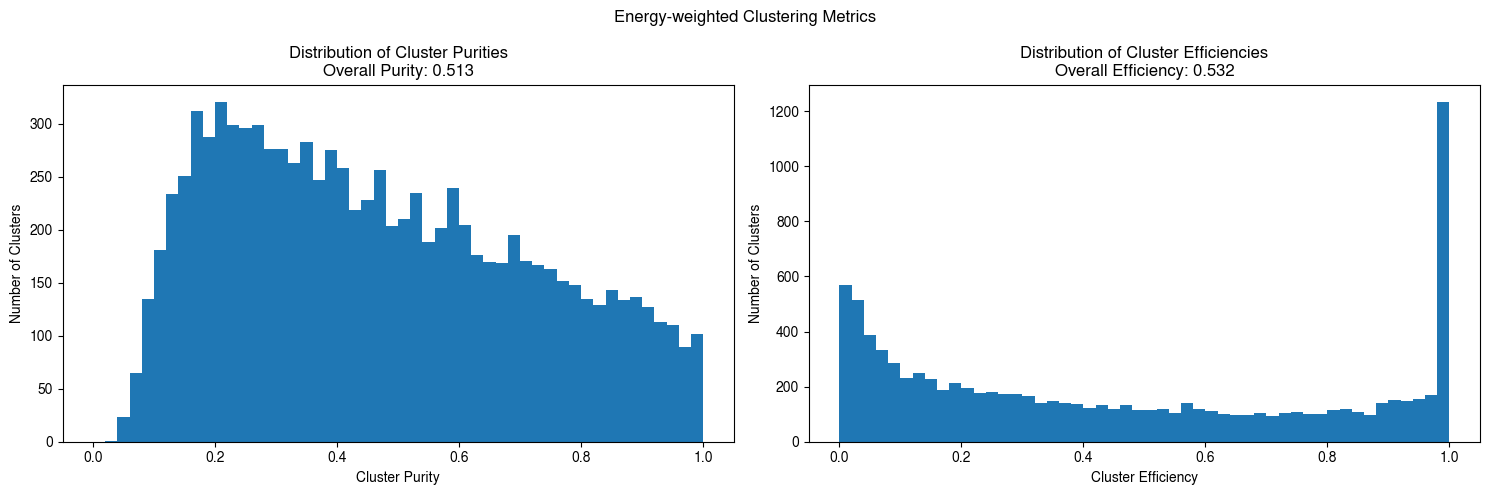

In [31]:
# First look at basic cluster statistics
cluster_sizes = pd.Series(calo_hits_df['kmeans_labels'].value_counts())
print("Cluster sizes:")
print(cluster_sizes)
print("\nTotal points:", cluster_sizes.sum())

# Now evaluate the clustering
metrics_df, overall = evaluate_clustering(
    calo_hits_df, 
    energy_weighted=True, 
    label_column='kmeans_labels', 
    energy_column='energy', 
    particle_id_column='highest_energy_particle_id'
)
plot_clustering_metrics(metrics_df, overall)

Starting clustering...
Init 1/1 with method k-means++
Inertia for init 1/1: 0.017760716378688812
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 1/35560: mean batch inertia: 3.4834278631024064e-07
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 2/35560: mean batch inertia: 3.085631178691983e-07, ewa inertia: 3.085631178691983e-07
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 3/35560: mean batch inertia: 3.162523207720369e-07, ewa inertia: 3.086063641081169e-07
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 4/35560: mean batch inertia: 2.790456055663526e-07, ewa inertia: 3.0844010609117223e-07
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 5/35560: mean batch inertia: 2.6585772866383194e-07, ewa inertia: 3.0820061082863164e-07
[MiniBatchKMeans] Reassigning 500 cluster centers.
Minibatch step 6/35560: mean batch inertia: 2.828983997460455e-07, ewa inertia: 3.0805830407987336e-07
[MiniBatchKMeans

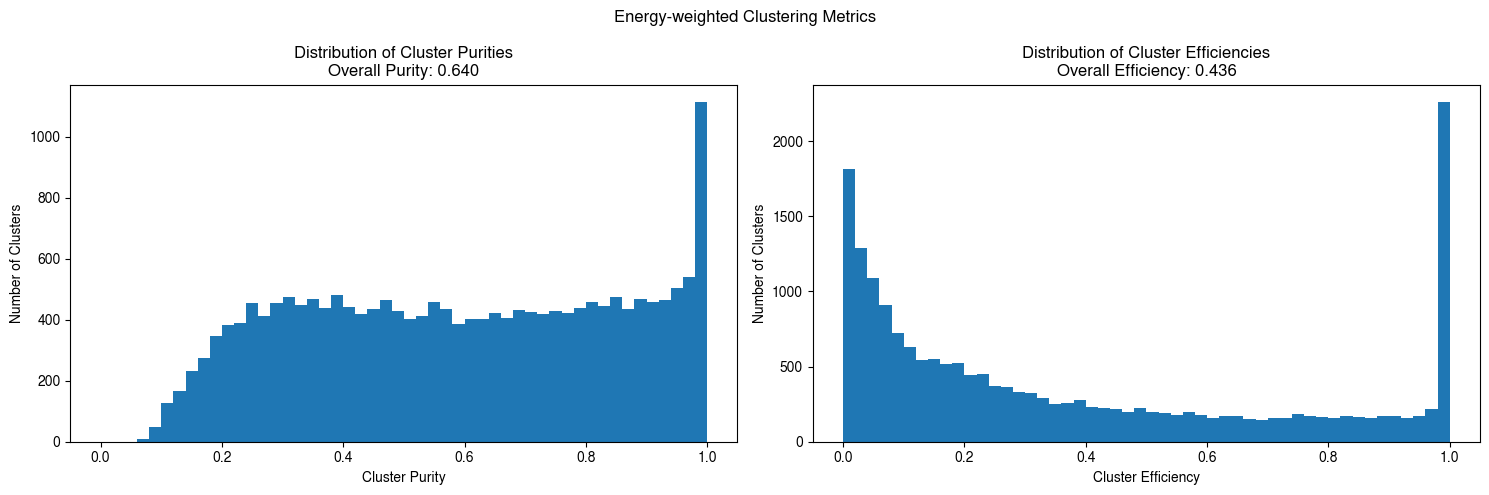

In [39]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
import time
import numpy as np

# Create a clean, C-contiguous copy of the data
data = np.ascontiguousarray(calo_hits_df[['x', 'y', 'z']].values, dtype=np.float32)
weights = np.ascontiguousarray(calo_hits_df['energy'].values, dtype=np.float32)

# Normalize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

print("Starting clustering...")
start_time = time.time()

kmeans = MiniBatchKMeans(
    n_clusters=20000,
    batch_size=1000,
    random_state=42,
    max_iter=100,
    verbose=1,
    tol=1e-4
)

# Use sample_weight parameter to weight by energy
kmeans.fit(data_scaled, sample_weight=weights)
end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")

# Map labels back to original dataframe
calo_hits_df['kmeans_labels'] = kmeans.labels_

# Evaluate and plot results
metrics_df, overall = evaluate_clustering(
    calo_hits_df, 
    energy_weighted=True,  # Use energy-weighted evaluation
    label_column='kmeans_labels', 
    energy_column='energy', 
    particle_id_column='highest_energy_particle_id'
)
plot_clustering_metrics(metrics_df, overall)

In [43]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
import time
import numpy as np

# Create a clean, C-contiguous copy of the data
data = np.ascontiguousarray(calo_hits_df[['eta', 'phi']].values, dtype=np.float32)
weights = np.ascontiguousarray(calo_hits_df['energy'].values, dtype=np.float32)

# Normalize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

print("Starting clustering...")
start_time = time.time()

kmeans = MiniBatchKMeans(
    n_clusters=20000,
    batch_size=1000,
    random_state=42,
    max_iter=100,
    verbose=1,
    tol=1e-4
)

# Use sample_weight parameter to weight by energy
kmeans.fit(data_scaled, sample_weight=weights)
end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")

# Map labels back to original dataframe
calo_hits_df['kmeans_labels'] = kmeans.labels_

# Evaluate and plot results
metrics_df, overall = evaluate_clustering(
    calo_hits_df, 
    energy_weighted=True,  # Use energy-weighted evaluation
    label_column='kmeans_labels', 
    energy_column='energy', 
    particle_id_column='highest_energy_particle_id'
)
plot_clustering_metrics(metrics_df, overall)

Starting clustering...
Init 1/1 with method k-means++


Cluster sizes:
1317    260
3464    214
9794    208
381     194
2566    192
       ... 
2222      2
6831      2
9725      2
2616      2
8276      1
Name: kmeans_labels, Length: 9502, dtype: int64

Total points: 355600


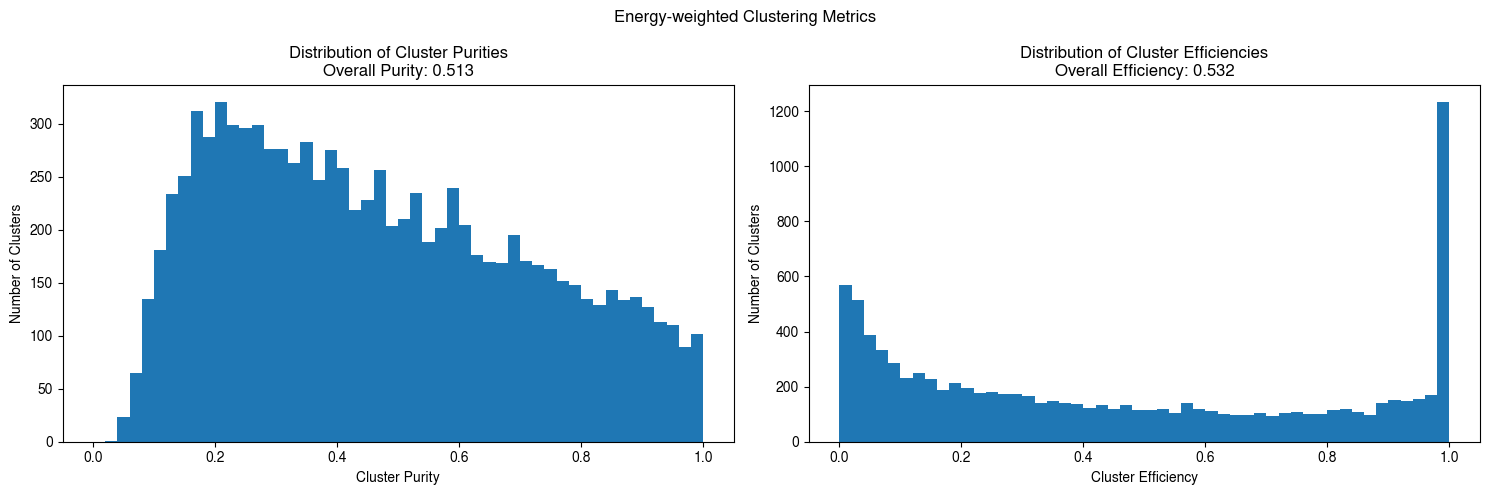

In [ ]:
# First look at basic cluster statistics
cluster_sizes = pd.Series(calo_hits_df['kmeans_labels'].value_counts())
print("Cluster sizes:")
print(cluster_sizes)
print("\nTotal points:", cluster_sizes.sum())

# Now evaluate the clustering
metrics_df, overall = evaluate_clustering(
    calo_hits_df, 
    energy_weighted=True, 
    label_column='kmeans_labels', 
    energy_column='energy', 
    particle_id_column='highest_energy_particle_id'
)
plot_clustering_metrics(metrics_df, overall)

Starting clustering...
Time taken: 22.32849383354187 seconds
Number of clusters: 6
Number of noise points: 128666 (36.2%)


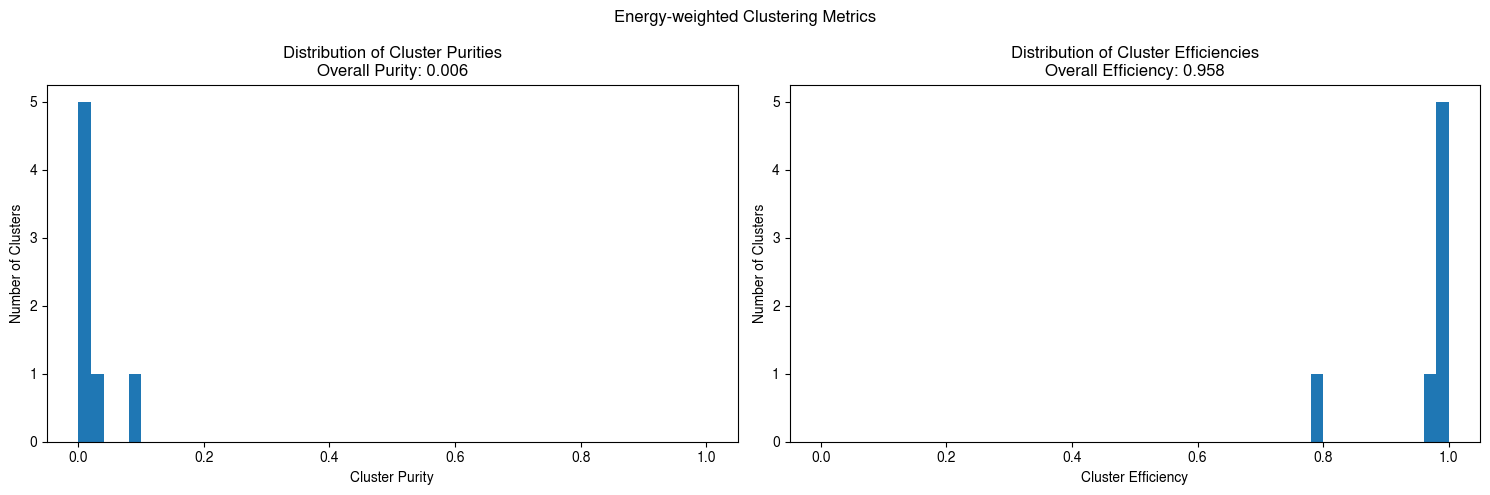

,energy,dominant_particle_id,correct_energy,purity,total_particle_energy,efficiency
dbscan_labels,,,,,,
-1,47.265110,3556405,0.095639,0.002023,0.095940,0.996864
0,25.088465,17111,0.161505,0.006437,0.161507,0.999986
1,27.888899,38941,0.165144,0.005922,0.165767,0.996245
2,25.992064,29912,0.109860,0.004227,0.140711,0.780750
3,16.528809,674620,0.132825,0.008036,0.133295,0.996470
4,1.431719,1435500,0.042440,0.029643,0.042440,1.000000
5,1.898227,53489,0.159864,0.084218,0.165099,0.968294


In [54]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import numpy as np
import time

# Prepare the data
data = np.ascontiguousarray(calo_hits_df[['eta', 'phi']].values, dtype=np.float32)
weights = np.ascontiguousarray(calo_hits_df['energy'].values, dtype=np.float32)

# Normalize spatial coordinates
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

print("Starting clustering...")
start_time = time.time()

# DBSCAN with energy weights
dbscan = DBSCAN(
    eps=0.14,
    min_samples=1,
    metric='euclidean',
    n_jobs=-1
)

# Fit with sample_weight parameter
dbscan.fit(data_scaled, sample_weight=weights)
end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")

# Map labels back to original dataframe
calo_hits_df['dbscan_labels'] = dbscan.labels_

# Print some basic clustering info
n_clusters = len(set(dbscan.labels_)) - (1 if -1 in dbscan.labels_ else 0)
n_noise = list(dbscan.labels_).count(-1)
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points: {n_noise} ({n_noise/len(data)*100:.1f}%)")

# Evaluate clustering (excluding noise points)
# Create a copy of the filtered DataFrame and reset its index
# clustered_df = calo_hits_df[calo_hits_df['dbscan_labels'] >= 0].copy().reset_index(drop=True)
clustered_df = calo_hits_df.copy().reset_index(drop=True)

metrics_df, overall = evaluate_clustering(
    clustered_df,
    energy_weighted=True,
    label_column='dbscan_labels', 
    energy_column='energy', 
    particle_id_column='highest_energy_particle_id'
)
plot_clustering_metrics(metrics_df, overall)
metrics_df

In [12]:
from sklearn.cluster import MeanShift
from sklearn.preprocessing import StandardScaler
import numpy as np
import time

# Prepare the data
data = np.ascontiguousarray(calo_hits_df[['eta', 'phi']].values, dtype=np.float32)
weights = np.ascontiguousarray(calo_hits_df['energy'].values, dtype=np.float32)

# Normalize spatial coordinates
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
data_scaled = data_scaled[:50000]
weights = weights[:50000]

print("Starting clustering...")
start_time = time.time()

# MeanShift clustering with energy weights
meanshift = MeanShift(
    bandwidth=0.1,  # Adjust bandwidth parameter as needed
    n_jobs=4
)

# Fit with sample_weight parameter
meanshift.fit(data_scaled)
end_time = time.time()
print(f"Time taken: {end_time - start_time} seconds")

# Map labels back to original dataframe
calo_hits_df['dbscan_labels'] = meanshift.labels_

# Print some basic clustering info
n_clusters = len(set(meanshift.labels_))
print(f"Number of clusters: {n_clusters}")

# Create a copy of the DataFrame and reset its index
clustered_df = calo_hits_df.copy().reset_index(drop=True)

metrics_df, overall = evaluate_clustering(
    clustered_df,
    energy_weighted=True,
    label_column='dbscan_labels', 
    energy_column='energy', 
    particle_id_column='highest_energy_particle_id'
)
plot_clustering_metrics(metrics_df, overall)
metrics_df

Starting clustering...
Time taken: 55.31054496765137 seconds


ValueError: Length of values (50000) does not match length of index (355600)

In [46]:
metrics_df

,energy,dominant_particle_id,correct_energy,purity,total_particle_energy,efficiency
dbscan_labels,,,,,,
0,5.421346,4108312,0.921536,0.169983,0.921536,1.000000
1,5.171498,1980,1.271938,0.245952,1.272113,0.999862
2,3.242600,4049239,0.814365,0.251146,0.814603,0.999708


In [48]:
calo_hits_df.energy.sum()

146.09329

## V-Score Metric

In [41]:
calo_hits_df

,cellID,energy,x,y,z,contribution_begin,contribution_end,r,R,phi,theta,eta,detector,highest_energy_particle_id,labels_pred,cluster_id
0,19703278443040784,1.836892e-09,35.700001,-1267.550049,357.000000,0,1,1268.052734,1317.348389,-1.542639,1.296366,0.277942,ECalBarrelCollection,96703,0,67354
1,18291088463137206288,6.815690e-06,1343.300049,61.200001,-2820.300049,1,2,1344.693481,3124.466797,0.045528,2.696684,-1.486345,ECalBarrelCollection,96900,1,17897
2,18292495838020694032,7.979669e-06,1333.199951,61.200001,-2794.800049,2,3,1334.603882,3097.107422,0.045872,2.696081,-1.484945,ECalBarrelCollection,96900,1,38053
3,18310510159220439056,6.901636e-07,1173.350220,-519.138733,-2473.500000,3,4,1283.064941,2786.477783,-0.416550,2.663078,-1.410875,ECalBarrelCollection,96897,2,6976
4,18327961818231109648,4.109088e-06,1441.609619,-359.765656,-2152.199951,4,5,1485.822876,2615.269287,-0.244563,2.537356,-1.165847,ECalBarrelCollection,97236,3,43565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355595,168322186405959696,3.216178e-07,354.943817,1323.353149,3049.800049,1632713,1632714,1370.127197,3343.430664,1.308748,0.422231,1.540336,ECalBarrelCollection,1850,43333,6258
355596,163255602465495056,7.675362e-07,396.503204,1317.070801,2958.000000,1632714,1632715,1375.459961,3262.154785,1.278377,0.435255,1.509007,ECalBarrelCollection,1850,43333,1617
355597,163537064557434896,1.236313e-08,418.368774,1329.878174,2963.100098,1632715,1632716,1394.133545,3274.686279,1.266007,0.439769,1.498352,ECalBarrelCollection,1850,43333,1617
355598,167759068948813840,1.204739e-05,538.703430,1247.237427,3034.500000,1632716,1632717,1358.603149,3324.754639,1.163081,0.420955,1.543454,ECalBarrelCollection,1850,43333,5942


In [42]:
from scoring_functions import weighted_v_score

homogeneity, completeness, v_score = weighted_v_score(calo_hits_df['highest_energy_particle_id'], calo_hits_df['labels_pred'], beta=1.0, labels_weight=calo_hits_df['energy'])

v_score, homogeneity, completeness

(0.9999999999999998, 0.9999999999999998, 0.9999999999999998)

In [43]:
# Let's mix up the labels a bit
fraction_to_mix = 0.5
mixed_labels = calo_hits_df.labels_pred.copy()
mixed_labels[np.random.choice(calo_hits_df.index, size=int(len(calo_hits_df)*fraction_to_mix), replace=False)] = np.random.randint(0, int(calo_hits_df.labels_pred.max()), size=int(len(calo_hits_df)*fraction_to_mix))
mixed_labels_df = calo_hits_df.copy()
mixed_labels_df['labels_pred'] = mixed_labels

In [44]:
homogeneity, completeness, v_score = weighted_v_score(mixed_labels_df['highest_energy_particle_id'], mixed_labels_df['labels_pred'], beta=1.0, labels_weight=mixed_labels_df['energy'])

v_score, homogeneity, completeness

(0.8617648232168125, 0.9121196138556142, 0.8166789621795403)

In [45]:
random_labels = np.random.randint(0, int(calo_hits_df.labels_pred.max()), size=len(calo_hits_df))
random_labels_df = calo_hits_df.copy()
random_labels_df['labels_pred'] = random_labels
homogeneity, completeness, v_score = weighted_v_score(random_labels_df['highest_energy_particle_id'], random_labels_df['labels_pred'], beta=1.0, labels_weight=random_labels_df['energy'])

v_score, homogeneity, completeness

(0.7645679855437396, 0.8302564814883658, 0.7085117295427542)

In [46]:
# Let's just normalize to set the random number to 0
_, _, random_v_score = weighted_v_score(random_labels_df['highest_energy_particle_id'], random_labels_df['labels_pred'], beta=1.0, labels_weight=random_labels_df['energy'])

random_v_score


0.7645679855437396

In [ ]:
def adjusted_v_score(labels_true, labels_pred, beta=1.0, labels_weight=None):
    """Adjusted v-score that properly normalizes near-random performance."""
    # Get original score
    _, _, v_score = weighted_v_score(labels_true, labels_pred, beta=beta, labels_weight=labels_weight)
    
    # Get random baseline (using your existing method)
    n_clusters = len(np.unique(labels_true))
    random_labels = np.random.randint(0, n_clusters, size=len(labels_true))
    _, _, random_v_score = weighted_v_score(labels_true, random_labels, beta=beta, labels_weight=labels_weight)
    
    # If we're very close to random performance, return 0
    if np.abs(v_score - random_v_score) < 1e-10:
        return 0.0
        
    # Calculate adjusted score
    adjusted = (v_score - random_v_score) / (1 - random_v_score)
    
    # Clip to reasonable range
    return np.clip(adjusted, 0.0, 1.0)

def debug_v_score(labels_true, labels_pred, labels_weight=None):
    # Get original v-score
    _, _, v_score = weighted_v_score(labels_true, labels_pred, beta=1.0, labels_weight=labels_weight)
    print(f"Original v_score: {v_score}")
    
    # Get random baseline
    n_clusters = len(np.unique(labels_true))
    random_labels = np.random.randint(0, n_clusters, size=len(labels_true))
    _, _, random_v_score = weighted_v_score(labels_true, random_labels, beta=1.0, labels_weight=labels_weight)
    print(f"\nRandom baseline v_score: {random_v_score}")
    
    # Calculate adjusted score
    adjusted = (v_score - random_v_score) / (1 - random_v_score)
    print(f"\nAdjusted v_score: {adjusted}")
    
    return v_score, random_v_score, adjusted

# Test with your data
v_score, random_v, adjusted = debug_v_score(
    random_labels_df['highest_energy_particle_id'],
    random_labels_df['labels_pred'],
    random_labels_df['energy']
)

Original v_score: 0.7645679855437396

Random baseline v_score: 0.7645749042614545

Adjusted v_score: -2.9388191149078222e-05


In [74]:
v_score = adjusted_v_score(calo_hits_df['highest_energy_particle_id'], calo_hits_df['labels_pred'], beta=1.0, labels_weight=calo_hits_df['energy'])
v_score


0.9999999999999991

In [75]:
v_score = adjusted_v_score(mixed_labels_df['highest_energy_particle_id'], mixed_labels_df['labels_pred'], beta=1.0, labels_weight=mixed_labels_df['energy'])
v_score

0.41292020305512994

In [76]:
v_score = adjusted_v_score(random_labels_df['highest_energy_particle_id'], random_labels_df['labels_pred'], beta=1.0, labels_weight=random_labels_df['energy'])
v_score

0.00035137958974876845

In [73]:
v_score = adjusted_v_score(random_labels_df['highest_energy_particle_id'], random_labels_df['labels_pred'], beta=1.0, labels_weight=random_labels_df['energy'])
v_score

0.0

In [54]:
v_score = adjusted_v_score(random_labels_df['highest_energy_particle_id'], random_labels_df['labels_pred'], beta=1.0, labels_weight=random_labels_df['energy'])
v_score

-0.0012004300776641697

## Adjusted V-Score with Random Labels

In [ ]:
# Use adjusted rand index
from sklearn.metrics import adjusted_rand_score
adjusted_rand_score(calo_hits_df['highest_energy_particle_id'], calo_hits_df['labels_pred'])


1.0

In [ ]:
adjusted_rand_score(random_labels_df['highest_energy_particle_id'], random_labels_df['labels_pred'])

6.92252694679795e-08

In [ ]:
from sklearn.metrics.cluster._supervised import expected_mutual_information

In [ ]:
from scoring_functions import weighted_v_score, weighted_entropy, weighted_contingency_matrix

def adjusted_v_score_direct(labels_true, labels_pred, beta=1.0):
    """V-measure adjusted for chance using direct adjustment.
    
    Adjusts the final V-score rather than its components.
    """
    # Calculate actual V-score
    _, _, v_score = weighted_v_score(labels_true, labels_pred, beta=beta)
    
    print(f"V-score: {v_score}")

    # Calculate expected V-score under random labeling
    contingency = weighted_contingency_matrix(labels_true, labels_pred, sparse=True)
    n_samples = len(labels_true)

    print(f"Contingency: {contingency}")
    
    # Calculate expected scores
    emi = expected_mutual_information(contingency, n_samples)
    entropy_C = weighted_entropy(labels_true)
    entropy_K = weighted_entropy(labels_pred)

    print(f"EMI: {emi}")
    print(f"Entropy C: {entropy_C}")
    print(f"Entropy K: {entropy_K}")
    
    # Calculate expected homogeneity and completeness
    exp_homogeneity = emi / entropy_C if entropy_C else 1.0
    exp_completeness = emi / entropy_K if entropy_K else 1.0
    
    print(f"Expected homogeneity: {exp_homogeneity}")
    print(f"Expected completeness: {exp_completeness}")
    
    # Calculate expected V-score
    exp_v = ((1 + beta) * exp_homogeneity * exp_completeness / 
             (beta * exp_homogeneity + exp_completeness))
    
    print(f"Expected V-score: {exp_v}")
    # Adjust V-score
    max_v = 1.0  # V-score is already normalized
    adj_v = (v_score - exp_v) / (max_v - exp_v)
    
    return adj_v

In [ ]:
import numpy as np
from scipy import sparse
from scipy import special
from scipy.special import logsumexp

def optimized_expected_mutual_information(contingency, n_samples):
    """Calculate expected mutual information for two clusterings."""
    if isinstance(contingency, np.ndarray):
        nzx, nzy = np.nonzero(contingency)
        nz_val = contingency[nzx, nzy]
    else:
        nzx, nzy, nz_val = sparse.find(contingency)
        
    # Get row/column sums
    a = np.ravel(contingency.sum(axis=1))
    b = np.ravel(contingency.sum(axis=0))
    
    n_samples_f = float(n_samples)
    log_n_samples = np.log(n_samples_f)
    emi = 0.0
    
    # Calculate for each non-zero element
    for i in range(len(nz_val)):
        a_i = a[nzx[i]]
        b_j = b[nzy[i]]
        
        # Calculate start and end points
        start = max(1, a_i + b_j - n_samples)
        end = min(a_i, b_j)
        
        # Skip if invalid range
        if start > end:
            continue
            
        # Create range of values
        n_ij_range = np.arange(start, end + 1, dtype=np.float64)
        
        # Calculate log combinations
        log_combs = (
            log_comb(a_i, n_ij_range) +
            log_comb(b_j, n_ij_range) +
            log_comb(n_samples - a_i, b_j - n_ij_range) -
            log_comb(n_samples, b_j)  # Normalize probability
        )
        
        # Calculate mutual information terms in log space
        log_mutual_info = (
            np.log(n_ij_range) + 
            log_n_samples - 
            np.log(a_i) - 
            np.log(b_j)
        )
        
        # Combine terms using logsumexp for numerical stability
        log_terms = log_combs + log_mutual_info
        emi += np.sum(n_ij_range / n_samples_f * np.exp(log_terms))
    
    return emi

def log_comb(n, k):
    """Log combination calculation."""
    if np.any(k < 0) or np.any(k > n):
        return -np.inf
    
    return (
        special.gammaln(n + 1) -
        special.gammaln(k + 1) -
        special.gammaln(n - k + 1)
    )

In [ ]:
_, _, v_score = weighted_v_score(calo_hits_df['highest_energy_particle_id'], calo_hits_df['labels_pred'], beta=1.0, labels_weight=calo_hits_df['energy'])
v_score


0.9999999999999998

In [ ]:
_, _, v_score = weighted_v_score(random_labels_df['highest_energy_particle_id'], random_labels_df['labels_pred'], beta=1.0)
v_score


0.7225229314585535

In [ ]:
contingency = weighted_contingency_matrix(calo_hits_df['highest_energy_particle_id'], calo_hits_df['labels_pred'], sparse=True)
n_samples = len(calo_hits_df['highest_energy_particle_id'])
contingency, n_samples

(<43334x43334 sparse matrix of type '<class 'numpy.float64'>'
 	with 43334 stored elements in Compressed Sparse Row format>,
 355600)

In [ ]:
# Calculate expected scores
emi = optimized_expected_mutual_information(contingency, n_samples)

In [ ]:
entropy_C = weighted_entropy(calo_hits_df['highest_energy_particle_id'])
entropy_K = weighted_entropy(calo_hits_df['labels_pred'])

print(f"EMI: {emi}")
print(f"Entropy C: {entropy_C}")
print(f"Entropy K: {entropy_K}")

EMI: 2.474862285813375e+121
Entropy C: 9.394083095081063
Entropy K: 9.394083095081061


In [ ]:
# Calculate expected homogeneity and completeness
exp_homogeneity = emi / entropy_C if entropy_C else 1.0
exp_completeness = emi / entropy_K if entropy_K else 1.0

print(f"Expected homogeneity: {exp_homogeneity}")
print(f"Expected completeness: {exp_completeness}")

# Calculate expected V-score
exp_v = ((1 + 1) * exp_homogeneity * exp_completeness / 
            (1 * exp_homogeneity + exp_completeness))

print(f"Expected V-score: {exp_v}")
# Adjust V-score
max_v = 1.0  # V-score is already normalized
adj_v = (v_score - exp_v) / (max_v - exp_v)

Expected homogeneity: 5.488588947729886e+119
Expected completeness: 5.488588947729888e+119
Expected V-score: 5.488588947729887e+119


In [ ]:
adj_v

1.0

In [ ]:
adjusted_v_score_direct(calo_hits_df['highest_energy_particle_id'], calo_hits_df['labels_pred'])

In [ ]:
adjusted_v_score_direct(random_labels_df['highest_energy_particle_id'], random_labels_df['labels_pred'])

In [30]:
import numpy as np
from scipy import sparse
from scipy import special

def log_comb(n, k):
    """Compute log of binomial coefficient.
    
    log(C(n,k)) = log(n!/(k!(n-k)!)) = log(n!) - log(k!) - log((n-k)!)
    Using gammaln for numerical stability with large numbers.
    """
    if np.any(k < 0) or np.any(k > n):
        return -np.inf
    return (
        special.gammaln(n + 1) 
        - special.gammaln(k + 1) 
        - special.gammaln(n - k + 1)
    )

def hypergeom_pmf_in_log_space(a_i, b_j, N):
    """Compute hypergeometric PMF in log space.
    
    For each valid x, computes:
    P(X=x) = C(a_i,x) * C(N-a_i,b_j-x) / C(N,b_j)
    
    Returns valid x values and their log probabilities.
    """
    # Valid range for x: max(1, a_i+b_j-N) <= x <= min(a_i,b_j)
    start = max(1, a_i + b_j - N)
    end = min(a_i, b_j)
    
    if start > end:
        return np.array([]), np.array([])
        
    x_vals = np.arange(start, end + 1, dtype=np.float64)
    
    # Compute log probabilities
    log_num = log_comb(a_i, x_vals) + log_comb(N - a_i, b_j - x_vals)
    log_den = log_comb(N, b_j)
    log_pvals = log_num - log_den
    
    return x_vals, log_pvals

def emi_reference(contingency, n_samples):
    """Compute Expected Mutual Information.
    
    EMI = sum_ij sum_x P(x) * (x/N) * log((x*N)/(a_i*b_j))
    where x follows hypergeometric distribution with parameters N, a_i, b_j
    
    Parameters:
    -----------
    contingency : array-like or sparse matrix
        Contingency matrix between two clusterings
    n_samples : int
        Total number of samples
        
    Returns:
    --------
    emi : float
        Expected mutual information
    """
    # Convert sparse to dense if needed
    if sparse.issparse(contingency):
        contingency = contingency.toarray()
    
    # Get row and column sums
    a = contingency.sum(axis=1)  # row sums
    b = contingency.sum(axis=0)  # column sums
    
    # Initialize EMI
    emi = 0.0
    N_float = float(n_samples)
    
    # For each combination of row and column
    for i in range(len(a)):
        a_i = a[i]
        if a_i == 0:  # Skip empty rows
            continue
            
        for j in range(len(b)):
            b_j = b[j]
            if b_j == 0:  # Skip empty columns
                continue
            
            # Get valid x values and their probabilities
            x_vals, log_pvals = hypergeom_pmf_in_log_space(a_i, b_j, n_samples)
            if len(x_vals) == 0:
                continue
            
            # Convert log probabilities to probabilities
            pvals = np.exp(log_pvals)
            
            # Compute mutual information terms
            # MI = (x/N) * log((x*N)/(a_i*b_j))
            #    = (x/N) * (log(x) + log(N) - log(a_i) - log(b_j))
            log_mi_terms = (
                np.log(x_vals) +      # log(x)
                np.log(N_float) -     # log(N)
                np.log(a_i) -         # log(a_i)
                np.log(b_j)           # log(b_j)
            )
            
            # Multiply by x/N
            x_div_N = x_vals / N_float
            
            # Sum up the contribution from this i,j pair
            emi += np.sum(pvals * x_div_N * log_mi_terms)
    
    return emi

In [31]:
def optimized_expected_mutual_information_v2(contingency, n_samples):
    """Calculate expected mutual information for two clusterings."""
    if isinstance(contingency, np.ndarray):
        nzx, nzy = np.nonzero(contingency)
        nz_val = contingency[nzx, nzy]
    else:
        nzx, nzy, nz_val = sparse.find(contingency)
        
    # Get row/column sums
    a = np.ravel(contingency.sum(axis=1))
    b = np.ravel(contingency.sum(axis=0))
    
    n_samples_f = float(n_samples)
    emi = 0.0
    
    # Calculate for each unique (row, column) pair
    for i in range(len(a)):
        a_i = a[i]
        if a_i == 0:
            continue
            
        for j in range(len(b)):
            b_j = b[j]
            if b_j == 0:
                continue
                
            # Get valid x range and probabilities
            x_vals, log_pvals = hypergeom_pmf_in_log_space(a_i, b_j, n_samples)
            if len(x_vals) == 0:
                continue
                
            # Convert to probabilities
            pvals = np.exp(log_pvals)
            
            # Calculate MI terms
            log_mi_part = (
                np.log(x_vals) +
                np.log(n_samples_f) -
                np.log(a_i) -
                np.log(b_j)
            )
            
            # Multiply by x/N
            x_div_N = x_vals / n_samples_f
            
            # Add to total EMI
            emi += np.sum(pvals * x_div_N * log_mi_part)
    
    return emi

In [9]:
def optimized_expected_mutual_information_fixed(contingency, n_samples):
    """Calculate expected mutual information for two clusterings."""
    if sparse.issparse(contingency):
        contingency = contingency.toarray()
        
    # Get ALL row/column sums
    a = contingency.sum(axis=1)
    b = contingency.sum(axis=0)
    
    n_samples_f = float(n_samples)
    emi = 0.0
    
    # Loop over ALL row/column pairs
    for i in range(len(a)):
        a_i = a[i]
        if a_i == 0:
            continue
            
        for j in range(len(b)):
            b_j = b[j]
            if b_j == 0:
                continue
                
            # Get valid x range and probabilities
            start = max(1, a_i + b_j - n_samples)
            end = min(a_i, b_j)
            
            if start > end:
                continue
                
            x_vals = np.arange(start, end + 1, dtype=np.float64)
            
            # Calculate probabilities in log space
            log_num = (
                log_comb(a_i, x_vals) +
                log_comb(n_samples - a_i, b_j - x_vals)
            )
            log_den = log_comb(n_samples, b_j)
            log_pvals = log_num - log_den
            
            # Convert to probabilities
            pvals = np.exp(log_pvals)
            
            # Calculate MI terms
            log_mi_terms = (
                np.log(x_vals) +
                np.log(n_samples_f) -
                np.log(a_i) -
                np.log(b_j)
            )
            
            # Final calculation
            x_div_N = x_vals / n_samples_f
            emi += np.sum(pvals * x_div_N * log_mi_terms)
    
    return emi

In [11]:
# Test the reference implementation
def test_implementations(labels_true, labels_pred):
    # Get contingency matrix
    contingency = contingency_matrix(labels_true, labels_pred, sparse=True)
    n_samples = len(labels_true)

    # time_start = time.time()
    
    # # Calculate using reference implementation
    # emi_ref = emi_reference(contingency, n_samples)
    
    # time_end = time.time()
    # print(f"Reference EMI time: {time_end - time_start} seconds")
    
    # time_start = time.time()
    # # Calculate using optimized implementation
    # emi_opt = optimized_expected_mutual_information_fixed(contingency, n_samples)
    
    # time_end = time.time()
    # print(f"Optimized EMI time: {time_end - time_start} seconds")
    
    # print(f"Reference EMI: {emi_ref}")
    # print(f"Optimized EMI: {emi_opt}")
    
    time_start = time.time()
    # Also compare with sklearn's implementation
    from sklearn.metrics.cluster._expected_mutual_info_fast import expected_mutual_information
    emi_sklearn = expected_mutual_information(contingency.toarray(), n_samples)
    time_end = time.time()
    print(f"Sklearn EMI time: {time_end - time_start} seconds")
    print(f"Sklearn EMI: {emi_sklearn}")

In [10]:
from sklearn.metrics.cluster._supervised import contingency_matrix, expected_mutual_information

In [17]:
# Generate some test data
np.random.seed(42)
n_samples = 100000
labels_true = np.random.randint(0, 5000, n_samples)
labels_pred = np.random.randint(0, 5000, n_samples)

# Test both implementations
test_implementations(labels_true, labels_pred)

Sklearn EMI time: 25.56536364555359 seconds
Sklearn EMI: 5.47445910000019


In [40]:
# Test data
labels_true = [0, 0, 1, 1]
labels_pred = [0, 0, 1, 1]
cont = contingency_matrix(labels_true, labels_pred, sparse=True)

# Compare all versions
print(f"Reference EMI: {emi_reference(cont, len(labels_true))}")
print(f"Fixed Optimized EMI: {optimized_expected_mutual_information_fixed(cont, len(labels_true))}")
print(f"Sklearn EMI: {expected_mutual_information(cont.toarray(), len(labels_true))}")

Reference EMI: 0.2310490601866484
Fixed Optimized EMI: 0.2310490601866484
Sklearn EMI: 0.23104906018664825
